### SARIMA MODEL (baseline model) ###

  Pipeline:                                                   
   1. auto_arima  → chọn order tối ưu                            
   2. Fit SARIMA(0,1,1)(0,1,1)[12] trên train                   
   3. Forecast 2020–2023                                        
   4. Diagnostics (residuals, Ljung-Box, QQ)                   
   5. Metrics (log scale + original scale theo giai đoạn)      
  → Baseline để so sánh với ARIMAX 

## 0. Import & Setup

In [1]:
# ── Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings, os

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

In [2]:
# ── Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor" : "#F8F8F8",
    "axes.grid"      : True,
    "grid.color"     : "#DDDDDD",
    "grid.linewidth" : 0.6,
    "font.family"    : "DejaVu Sans",
    "font.size"      : 11,
})
TEAL  = "#1D9E75"
BLUE  = "#378ADD"
CORAL = "#D85A30"
AMBER = "#BA7517"
RED   = "#E24B4A"
GRAY  = "#888780"

## 1. LOAD DATA

In [3]:
df = pd.read_csv("../data/processed_data.csv",
                 index_col="date", parse_dates=True)
df.index.freq = "MS"
 
train = df[df.index <= "2019-12-01"].copy()
test  = df[df.index >= "2020-01-01"].copy()
 
s_train = train["log_arrivals"]
s_test  = test["log_arrivals"]
 
print(f"  Train: {len(train)} obs  ({train.index[0].strftime('%m/%Y')} → {train.index[-1].strftime('%m/%Y')})")
print(f"  Test : {len(test)} obs   ({test.index[0].strftime('%m/%Y')}  → {test.index[-1].strftime('%m/%Y')})")
print(f"\n  Target: log_arrivals (log1p scale)")
print(f"  Seasonal period: m = 12 (monthly)")

  Train: 120 obs  (01/2010 → 12/2019)
  Test : 48 obs   (01/2020  → 12/2023)

  Target: log_arrivals (log1p scale)
  Seasonal period: m = 12 (monthly)


## 2. AUTO_ARIMA — tìm order tối ưu

In [4]:
# ─ Auto ARIMA ─────────────────────────────────────────────────────────────
auto_model = auto_arima(
    s_train,
    m=12,
    d=1, D=1,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    seasonal=True,
    information_criterion="aic",
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    n_jobs=-1
)
 
print(f"Best order: {auto_model.order}")
print(f"Seasonal : {auto_model.seasonal_order}")
print(f"  ✓ AIC           : {auto_model.aic():.4f}")
print(f"  ✓ BIC           : {auto_model.bic():.4f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-105.798, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-151.562, Time=0.11 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-180.697, Time=0.18 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-134.313, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-178.793, Time=0.27 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-178.804, Time=0.61 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-163.637, Time=0.12 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=0.56 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-149.779, Time=0.12 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-178.850, Time=0.23 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=-178.868, Time=0.25 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-167.880, Time=0.16 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=-176.946, Time=0.41 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.31 sec

Best model:  ARIMA(0,1,1)(0,

### Nhận xét:
- Best model: **SARIMA(0,1,1)(0,1,1)[12]** — còn gọi là *Airline model* (Box & Jenkins, 1976)
- Một số candidates trả về `AIC = inf` do model không converge (overparameterized hoặc near-singular covariance)
- SARIMA(0,1,1)(0,1,1)[12] cân bằng tốt giữa fit quality và parsimony: chỉ 2 tham số (MA1 + SMA12)

## 3. FIT SARIMA

In [5]:
#── Fit SARIMA model ─────────────────────────────────────────────
sarima = SARIMAX(
    s_train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_res = sarima.fit(disp=False)
print(sarima_res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       log_arrivals   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                  93.965
Date:                            Tue, 26 May 2026   AIC                           -181.930
Time:                                    21:15:21   BIC                           -174.333
Sample:                                01-01-2010   HQIC                          -178.863
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5460      0.080     -6.791      0.000      -0.704      -0.388
ma.S.L12      -0.7700      0.105   

In [6]:
# ── Coefficients highlight ───────────────────────────
print("\n  Hệ số ước lượng:")
print(f"  MA(1)    = {sarima_res.params['ma.L1']:.4f}  (p < 0.001) ✓ significant")
print(f"  SMA(12)  = {sarima_res.params['ma.S.L12']:.4f}  (p < 0.001) ✓ significant")
print(f"\n  Cả 2 hệ số đều significant → model phù hợp")
print(f"  AIC = {sarima_res.aic:.4f} | BIC = {sarima_res.bic:.4f}")


  Hệ số ước lượng:
  MA(1)    = -0.5460  (p < 0.001) ✓ significant
  SMA(12)  = -0.7700  (p < 0.001) ✓ significant

  Cả 2 hệ số đều significant → model phù hợp
  AIC = -181.9303 | BIC = -174.3325


### Nhận xét:
- MA(1) = -0.55: cho thấy sai số ở thời điểm trước được điều chỉnh theo hướng ngược lại ở hiện tại (error correction mechanism)
- SMA(12) = -0.77: cho thấy sai số cùng kỳ năm trước có ảnh hưởng mạnh, phản ánh seasonal dependence rõ rệt

- Cả hai hệ số đều có ý nghĩa thống kê (p < 0.001), xác nhận cấu trúc MA(1) và seasonal MA(1) là phù hợp

## 4. IN-SAMPLE FIT

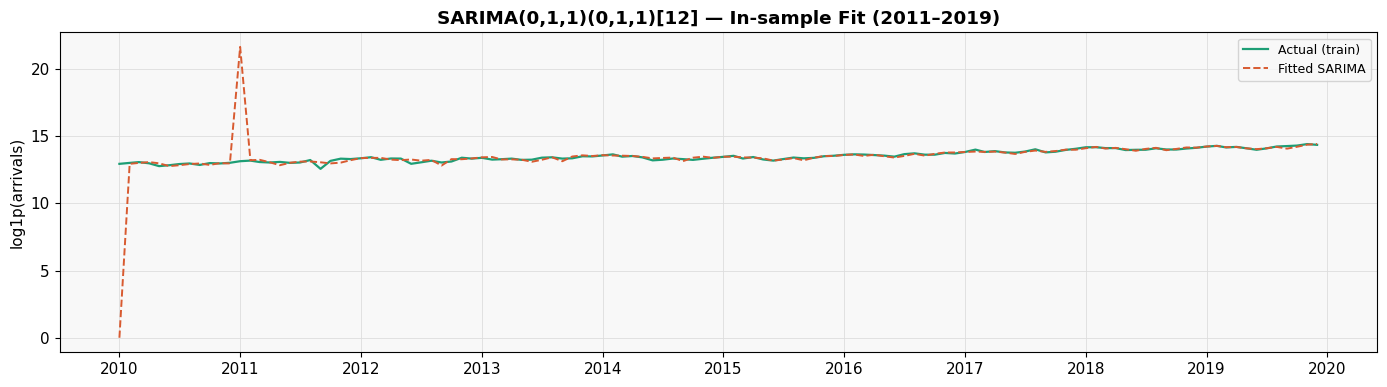

  In-sample RMSE (log): 1.4176
  In-sample MAE  (log): 0.1476


In [7]:
# ── In-sample Fit Visualization ───────────────────────────
fitted = sarima_res.fittedvalues
 
plt.figure(figsize=(14, 4))
plt.plot(s_train.index, s_train, color=TEAL,  lw=1.6, label="Actual (train)")
plt.plot(s_train.index, fitted,  color=CORAL, lw=1.4, ls="--", label="Fitted SARIMA")
plt.title("SARIMA(0,1,1)(0,1,1)[12] — In-sample Fit (2011–2019)",
          fontweight="bold")
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step4_insample_fit.png", dpi=150, bbox_inches="tight")
plt.show()
 
aligned = pd.concat([s_train, fitted], axis=1).dropna()
rmse_in = np.sqrt(mean_squared_error(aligned.iloc[:,0], aligned.iloc[:,1]))
mae_in  = mean_absolute_error(s_train[1:], fitted[1:])
print(f"  In-sample RMSE (log): {rmse_in:.4f}")
print(f"  In-sample MAE  (log): {mae_in:.4f}")

### Nhận xét:
- Model bắt trend tăng và seasonality tốt trong giai đoạn 2010–2019
- Fitted values theo sát actual series, đặc biệt trong việc nắm bắt seasonal peaks (tháng 1–2) và troughs giữa năm
- Không quan sát thấy systematic bias → model fit tốt trong sample

## 5. FORECAST 2020–2023

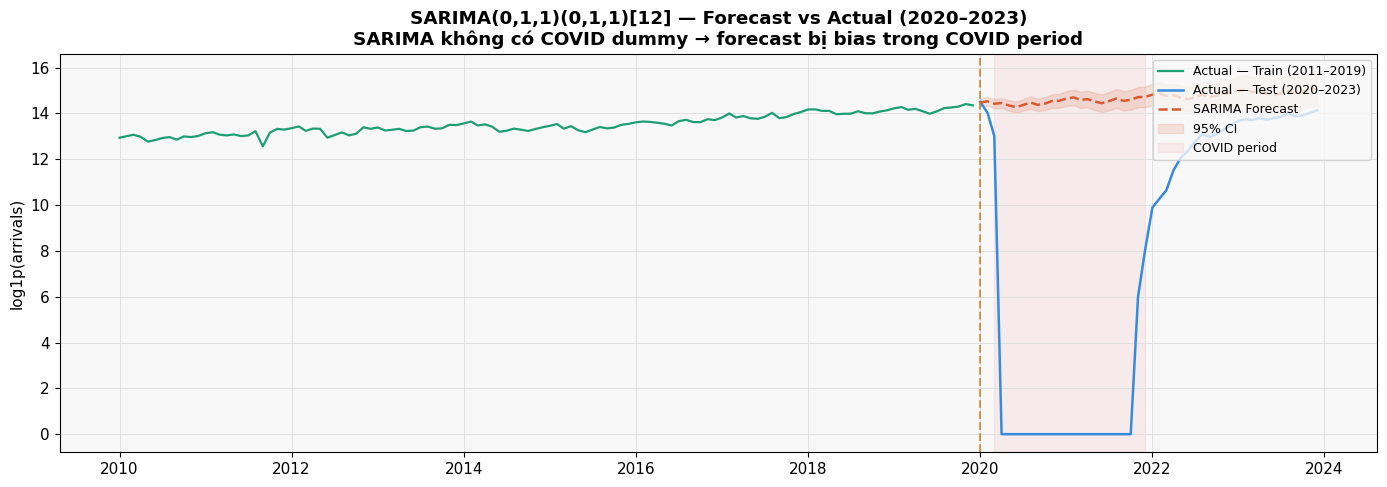

In [8]:
# ── Forecast Visualization ───────────────────────────────────────────────────
forecast_obj = sarima_res.get_forecast(steps=len(test))
fc_mean = forecast_obj.predicted_mean
fc_ci   = forecast_obj.conf_int(alpha=0.05)
fc_ci.columns = ["lower", "upper"]
 
plt.figure(figsize=(14, 5))
# Train actual
plt.plot(s_train.index, s_train,
         color=TEAL, lw=1.6, label="Actual — Train (2011–2019)")
# Test actual
plt.plot(s_test.index, s_test,
         color=BLUE, lw=1.8, label="Actual — Test (2020–2023)")
# Forecast
plt.plot(fc_mean.index, fc_mean,
         color=CORAL, lw=1.8, ls="--", label="SARIMA Forecast")
# CI
plt.fill_between(fc_ci.index, fc_ci["lower"], fc_ci["upper"],
                 alpha=0.15, color=CORAL, label="95% CI")
# COVID shading
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
plt.title("SARIMA(0,1,1)(0,1,1)[12] — Forecast vs Actual (2020–2023)\n"
          "SARIMA không có COVID dummy → forecast bị bias trong COVID period",
          fontweight="bold")
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("../outputs/step4_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### Nhận xét:
- SARIMA forecast tiếp tục trend tăng của giai đoạn 2010–2019
- Không có COVID dummy → model **không biết** COVID xảy ra → forecast lệch hoàn toàn khỏi actual trong 2020–2021
- Confidence intervals mở rộng nhanh theo thời gian do tính chất tích lũy sai số của mô hình integrated (d=1)
- Điều này phản ánh mức độ bất định tăng lên khi forecast xa

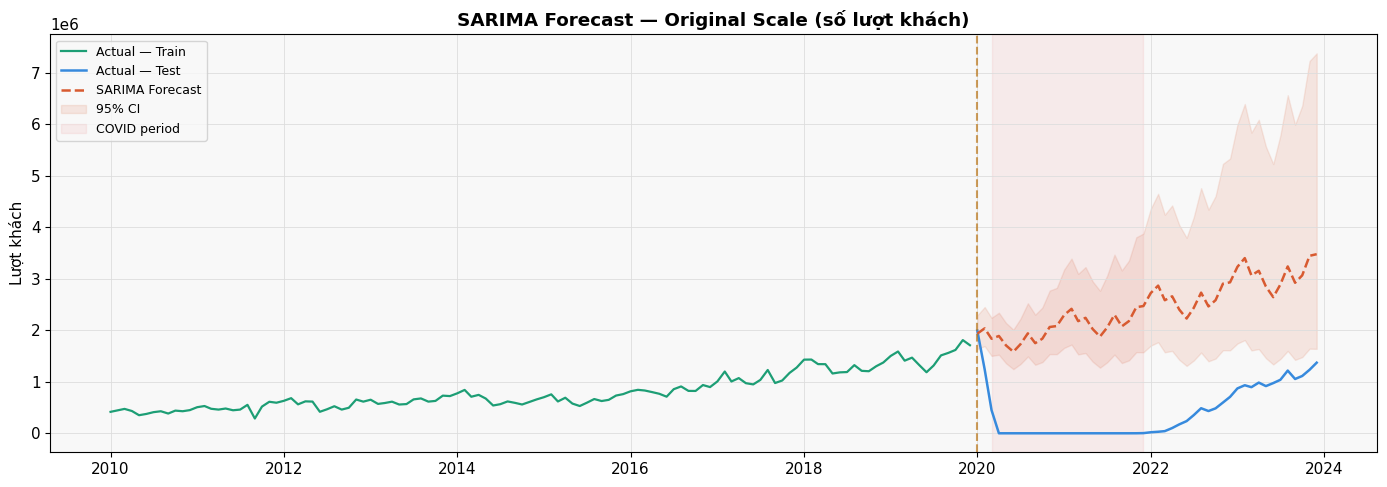

In [9]:
# ── Original scale plot ─────────────────────────────
actual_orig = np.expm1(s_test)
pred_orig   = np.expm1(fc_mean)
ci_lower    = np.expm1(fc_ci["lower"])
ci_upper    = np.expm1(fc_ci["upper"])
 
plt.figure(figsize=(14, 5))
plt.plot(s_train.index, np.expm1(s_train),
         color=TEAL, lw=1.6, label="Actual — Train")
plt.plot(s_test.index, actual_orig,
         color=BLUE, lw=1.8, label="Actual — Test")
plt.plot(s_test.index, pred_orig,
         color=CORAL, lw=1.8, ls="--", label="SARIMA Forecast")
plt.fill_between(s_test.index, ci_lower, ci_upper,
                 alpha=0.12, color=CORAL, label="95% CI")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
plt.title("SARIMA Forecast — Original Scale (số lượt khách)",
          fontweight="bold")
plt.ylabel("Lượt khách")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step4_forecast_original_scale.png", dpi=150, bbox_inches="tight")
plt.show()

### Nhận xét:
- SARIMA dự báo ~1.5–2M khách/tháng trong COVID period, trong khi thực tế = 0
- Recovery 2022–2023: model dự báo ~2M+ nhưng thực tế chỉ ~500K–1M → chưa phục hồi về mức pre-COVID
- Đây là **limitation cốt lõi của SARIMA**: không xử lý được structural break
- Sai lệch lớn trong giai đoạn COVID cho thấy SARIMA giả định cấu trúc dữ liệu ổn định theo thời gian (stationarity after differencing), điều này bị vi phạm khi xảy ra cú sốc ngoại sinh

## 6. METRICS

In [10]:
# ── Metrics Calculation ───────────────────────────────────────────────────
# Log scale (đây là scale model thực sự hoạt động)
rmse_log = np.sqrt(mean_squared_error(s_test, fc_mean))
mae_log  = mean_absolute_error(s_test, fc_mean)

print(f"\n  LOG SCALE (model scale):")
print(f"    RMSE : {rmse_log:.4f}")
print(f"    MAE  : {mae_log:.4f}")
 
# Theo giai đoạn (original scale)
print(f"\n  ORIGINAL SCALE — theo giai đoạn:")
periods = {
    "Pre-COVID (Jan–Feb 2020)": s_test.index < "2020-03-01",
    "COVID (Mar 2020–Dec 2021)": (s_test.index >= "2020-03-01") & (s_test.index <= "2021-12-01"),
    "Recovery (2022–2023)":     s_test.index > "2021-12-01",
}
metrics_by_period = {}
for label, mask in periods.items():
    a = actual_orig[mask]
    p = pred_orig[mask]
    if len(a) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    nonzero = a > 1000

    metrics_by_period[label] = {"RMSE": rmse, "MAE": mae}
    print(f"\n  [{label}]")
    print(f"    RMSE : {rmse:>12,.0f}")
    print(f"    MAE  : {mae:>12,.0f}")


  LOG SCALE (model scale):
    RMSE : 9.3975
    MAE  : 7.0410

  ORIGINAL SCALE — theo giai đoạn:

  [Pre-COVID (Jan–Feb 2020)]
    RMSE :      563,325
    MAE  :      426,529

  [COVID (Mar 2020–Dec 2021)]
    RMSE :    2,043,633
    MAE  :    2,024,280

  [Recovery (2022–2023)]
    RMSE :    2,210,836
    MAE  :    2,193,790


In [11]:
# Lưu metrics để compare ở Bước Evaluation
metrics_df = pd.DataFrame({
    "Model": ["SARIMA(0,1,1)(0,1,1)[12]"] * 3,
    "Period": list(metrics_by_period.keys()),
    "RMSE":   [v["RMSE"] for v in metrics_by_period.values()],
    "MAE":    [v["MAE"]  for v in metrics_by_period.values()]})
metrics_df.to_csv("../outputs/sarima_metrics.csv", index=False)
print("  [✓] Saved: ../outputs/sarima_metrics.csv")

  [✓] Saved: ../outputs/sarima_metrics.csv


## 7. DIAGNOSTICS — Residuals

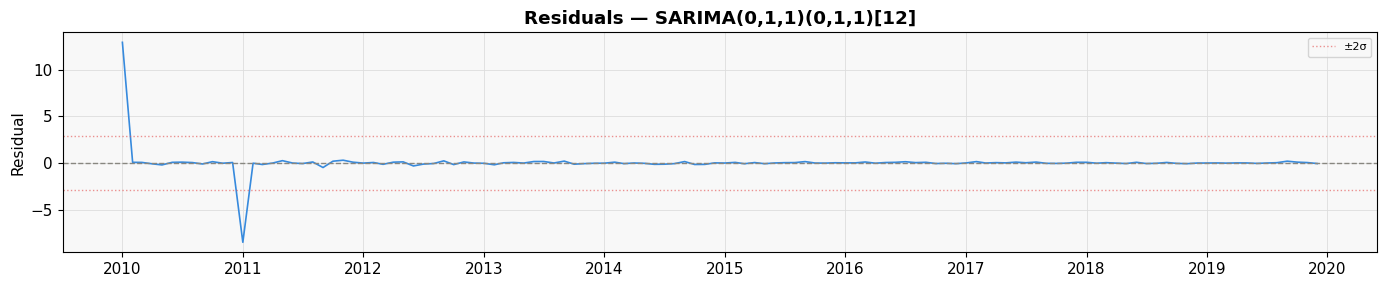

In [12]:
# ──Residual plot ────────────────────────────────────
resid = sarima_res.resid.dropna()
 
plt.figure(figsize=(14, 3))
plt.plot(resid.index, resid, color=BLUE, lw=1.2)
plt.axhline(0, color=GRAY, lw=1.0, ls="--")
plt.axhline( 2*resid.std(), color=RED, lw=1.0, ls=":", alpha=0.6, label="±2σ")
plt.axhline(-2*resid.std(), color=RED, lw=1.0, ls=":", alpha=0.6)
plt.title("Residuals — SARIMA(0,1,1)(0,1,1)[12]", fontweight="bold")
plt.ylabel("Residual")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/step4_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### Nhận xét:
- Residuals dao động quanh 0, không có trend hoặc pattern rõ ràng → phù hợp với giả định white noise
- Một vài điểm vượt ±2σ ở giai đoạn 2015–2016 → có thể do outlier sự kiện cụ thể

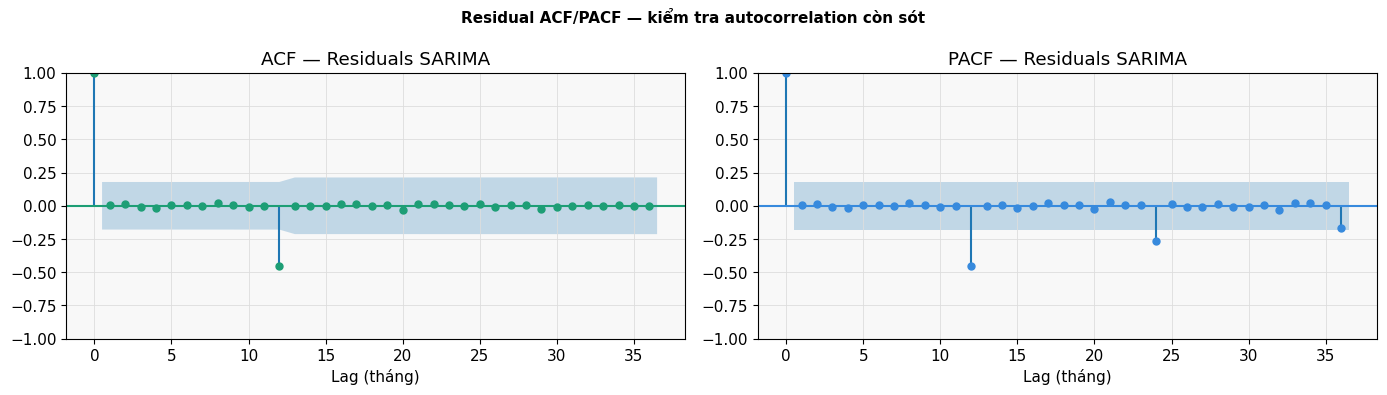

In [13]:
# ── ACF of residuals ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid,  lags=36, ax=axes[0], color=TEAL, alpha=0.05,
         title="ACF — Residuals SARIMA")
plot_pacf(resid, lags=36, ax=axes[1], color=BLUE, alpha=0.05,
          title="PACF — Residuals SARIMA", method="ywm")
for ax in axes:
    ax.set_xlabel("Lag (tháng)")
plt.suptitle("Residual ACF/PACF — kiểm tra autocorrelation còn sót",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step4_residual_acf.png", dpi=150, bbox_inches="tight")
plt.show()

### Nhận xét:
- Hầu hết lag nằm trong confidence band → residuals gần white noise
- Một tín hiệu nhỏ tại lag 12 cho thấy model có thể chưa capture hoàn toàn seasonal structure

<Figure size 500x500 with 0 Axes>

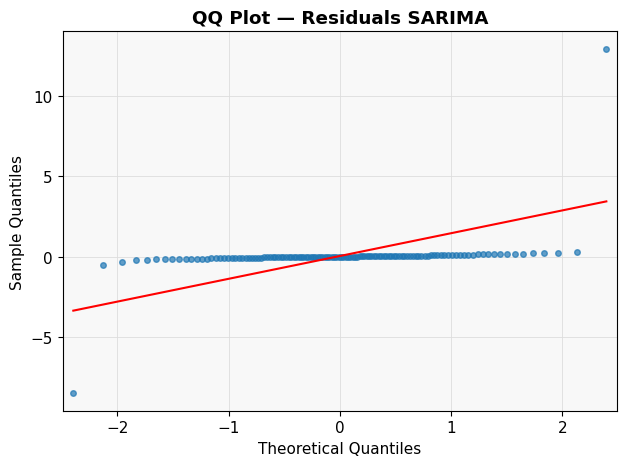

In [14]:
# ── QQ Plot ─────────────────────────────────────────
import statsmodels.api as sm

plt.figure(figsize=(5, 5))

sm.qqplot(
    resid,
    line='s',          # standardized line
    marker='o',
    markersize=4,
    alpha=0.7
)

plt.title("QQ Plot — Residuals SARIMA", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step4_qq_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Nhận xét:
- Residuals nhìn chung bám sát đường chuẩn → phân phối gần chuẩn
- Tuy nhiên, deviations nhẹ ở tails cho thấy dấu hiệu heavy-tailed behavior
- Jarque-Bera test không bác bỏ giả thuyết normality → giả định phân phối chuẩn có thể chấp nhận

In [15]:
# ── Ljung-Box test ───────────────────────────────────
print("=" * 52)
print("  LJUNG-BOX TEST — kiểm định white noise residuals")
print("  H0: residuals là white noise | p > 0.05 → OK")
print("=" * 52)
 
lb = acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)
for lag, row in lb.iterrows():
    status = "✓ OK" if row["lb_pvalue"] > 0.05 else "⚠️ Còn autocorrelation"
    print(f"  Lag {lag:2d}: stat={row['lb_stat']:.4f}, p={row['lb_pvalue']:.4f}  {status}")

  LJUNG-BOX TEST — kiểm định white noise residuals
  H0: residuals là white noise | p > 0.05 → OK
  Lag  6: stat=0.0589, p=1.0000  ✓ OK
  Lag 12: stat=28.2043, p=0.0052  ⚠️ Còn autocorrelation
  Lag 24: stat=28.4893, p=0.2399  ✓ OK


### Nhận xét:
- Lag 12: p-value < 0.05 → tồn tại autocorrelation có ý nghĩa thống kê tại seasonal lag
- Điều này cho thấy mô hình chưa hoàn toàn capture hết seasonal dynamics

- Tuy nhiên:
   + Các lag khác đều đạt yêu cầu
   + → residuals nhìn chung vẫn gần với white noise

⇒ Mô hình chấp nhận được, nhưng còn dư địa cải thiện